In [1]:
import numpy as np
import numba
import numba.cuda as cuda
import matplotlib.pyplot as plt

from gpu import CRUs, RyR_stationary, LCC_stationary, calculate_V_dep_LCC_params
from gpu.CRU3d import CRU3D
from params import RestrepoParams

In [2]:
N = 20 * 20 * 60
vi = 0.5 * 19305 / N#10_000 / N
vs = vnsr = 0.025 * 19305 / N
vjsr = 0.02 * 19305 / N
vp = 0.00126 * 19305 / N

params = RestrepoParams(Ku=1.4e-4, h=2.5, vup=0.36)

In [3]:
def Mhat(cj, params):
    """Calculate Mhat from rho"""
    K_cjsr_h = (params.K / cj) ** params.h
    rho = params.rho_inf / (1.0 + K_cjsr_h)
    rhoBCSQN = rho * params.BCSQN
    if rhoBCSQN < 1e-10:
        return 1.0 - 2.0 * rhoBCSQN
    return (np.sqrt(1.0 + 8.0 * rhoBCSQN) - 1.0) / (4.0 * rhoBCSQN)

In [4]:
def beta_j(cj, h, params):
    K_cjsr_h = (params.K / cj) ** h
    rho = params.rho_inf / (1.0 + K_cjsr_h)
    rhoBCSQN = rho * params.BCSQN
    Mhat = np.where(rhoBCSQN < 1e-10, 1.0 - 2.0 * rhoBCSQN, (np.sqrt(1.0 + 8.0 * rhoBCSQN) - 1.0) / (4.0 * rhoBCSQN))

    ncjsr = Mhat * params.nM + (1.0 - Mhat) * params.nD

    drho = (h * rho / cj) * (1.0 - rho / params.rho_inf)
    dMhat = (
        (-2.0 * params.BCSQN * Mhat**2)
        / (1.0 + 4.0 * Mhat * rho * params.BCSQN)
    ) * drho
    dn = dMhat * (params.nM - params.nD)
    return 1.0 / (
        1.0 + params.BCSQN * (params.KC * ncjsr + dn * (cj * params.KC + cj**2)) / (params.KC + cj)**2
    )

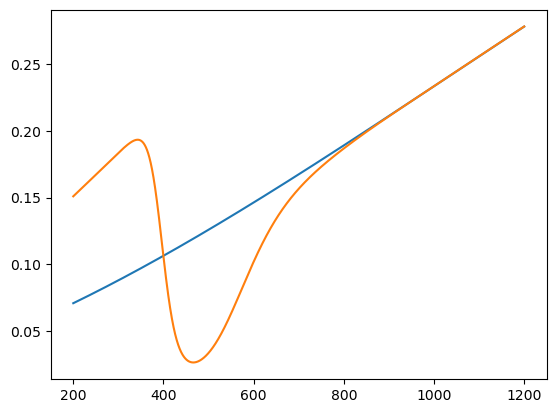

In [5]:
cj = np.linspace(200, 1200, num=10000)
plt.plot(cj, beta_j(cj, 2.5, params))
plt.plot(cj, beta_j(cj, 25, params))
plt.show()

In [6]:
ci = 0.2 * np.ones((60, 20, 20), dtype=np.float32)
cs = 0.2 * np.ones((60, 20, 20), dtype=np.float32)
cp = 0.2 * np.ones((60, 20, 20), dtype=np.float32)

cjsr = 1100.0 * np.ones((60, 20, 20), dtype=np.float32)
cnsr = 1100.0 * np.ones((60, 20, 20), dtype=np.float32)

CaTi = params.kon * params.BT * ci / (params.koff + params.kon * ci)
CaTs = params.kon * params.BT * cs / (params.koff + params.kon * cs)

k41 = 1 / params.tau_u
k14 = Mhat(1100.0, params) / params.tau_b

RyR = np.zeros((60, 20, 20, 4), dtype=np.float32)
RyR[..., 0] = k41 / (k41 + k14)
RyR[..., 3] = 1 - RyR[..., 0]

LCC = np.ones((60, 20, 20, 4), dtype=np.int32)

vp = params.vp * np.ones_like(ci)

In [10]:
cru3d = CRU3D(params, RyR, LCC, ci, cnsr, cjsr, cs, cp, CaTi, CaTs, vp=vp)
#cru3d_rapid = CRU3D(params, RyR, LCC, ci, cnsr, cjsr, cs, cp, CaTi, CaTs)

In [23]:
sol = cru3d.forward(1e-2, T=400.0, Vmax=0.0, Vmin=-85.0, nstep=1_000_000, collect_every=200, tpb=(16,4,4))

In [23]:
#sol_rapid = cru3d_rapid.forward(5e-3, T=400.0, Vmax=0.0, Vmin=-85.0, nstep=100_000, collect_every=200, tpb=(16,4,4), cs_rapid_eq=True)

In [24]:
ICa = sol.ICa()
INCX = sol.INCX()

#ICa_rapid = sol_rapid.ICa()
#INCX_rapid = sol_rapid.INCX()

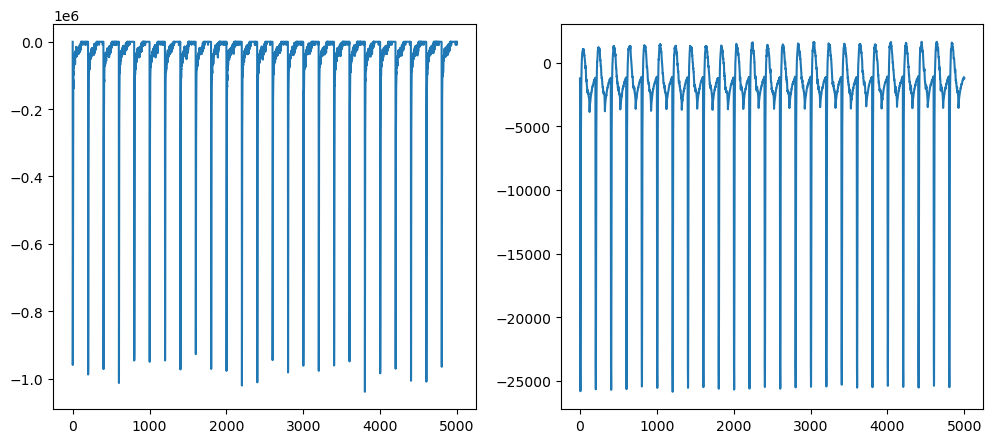

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].plot(ICa.sum(axis=(1,2,3)))
#ax[0].plot(ICa_rapid.sum(axis=(1,2,3)))

ax[1].plot(INCX.sum(axis=(1,2,3)))
#ax[1].plot(INCX_rapid.sum(axis=(1,2,3)))
plt.show()

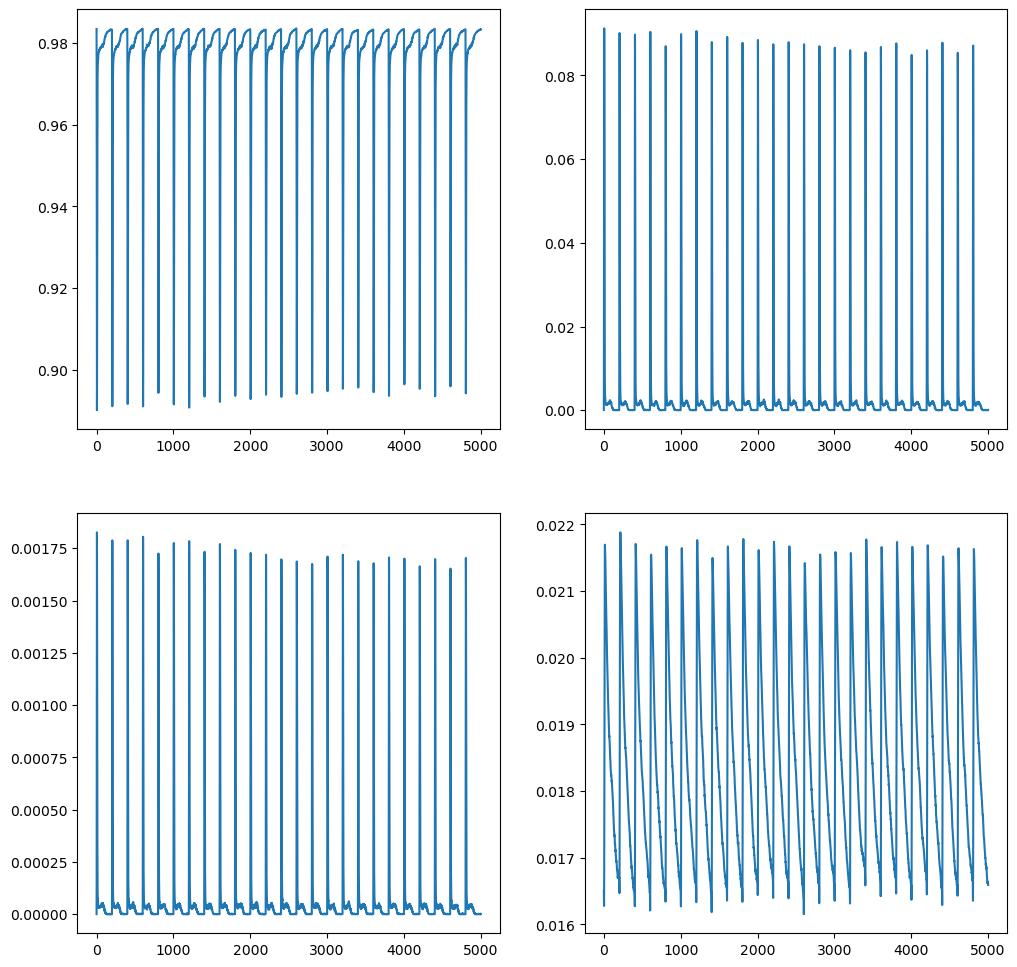

In [26]:
fig, ax = plt.subplots(2, 2, figsize=(12,12))
ax[0, 0].plot(sol.RyR[..., 0].mean(axis=(1,2,3)))
#ax[0, 0].plot(sol_tau.RyR[..., 0].mean(axis=(1,2,3)))

ax[0, 1].plot(sol.RyR[..., 1].mean(axis=(1,2,3)))
#ax[0, 1].plot(sol_tau.RyR[..., 1].mean(axis=(1,2,3)))

ax[1, 0].plot(sol.RyR[..., 2].mean(axis=(1,2,3)))
#ax[1, 0].plot(sol_tau.RyR[..., 2].mean(axis=(1,2,3)))

ax[1, 1].plot(sol.RyR[..., 3].mean(axis=(1,2,3)))
#ax[1, 1].plot(sol_tau.RyR[..., 3].mean(axis=(1,2,3)))
plt.show()

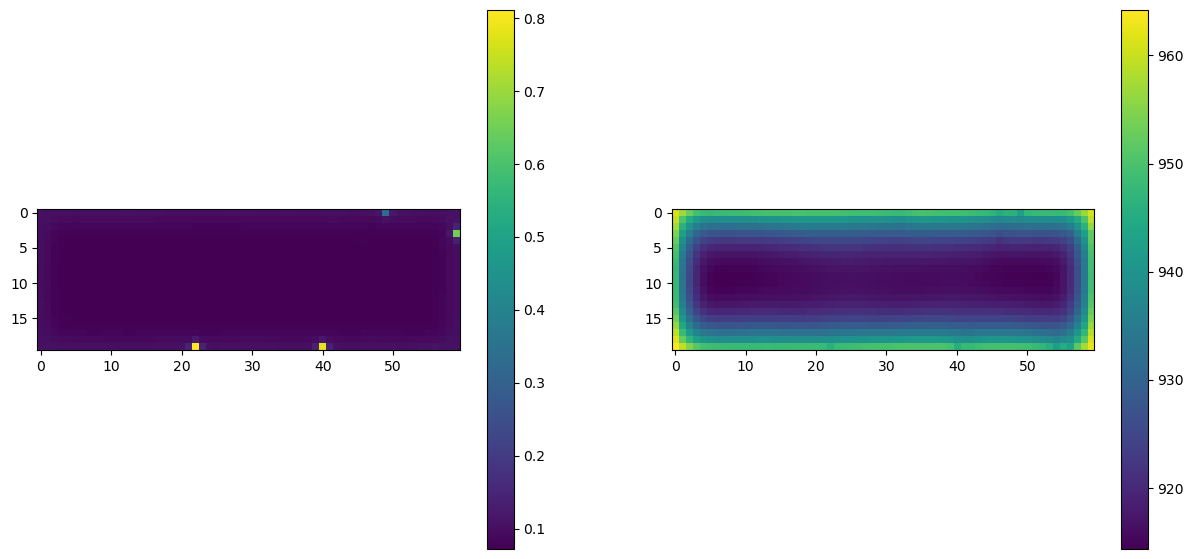

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(15,7))
p1 = ax[0].imshow(sol.cs[-1, ...].mean(axis=-1).T)
p2 = ax[1].imshow(sol.cnsr[-1, ...].mean(axis=-1).T)
#p2 = ax[1].imshow(sol_rapid.cjsr[350, ...].mean(axis=-1).T)
fig.colorbar(p1)
fig.colorbar(p2)
plt.show()

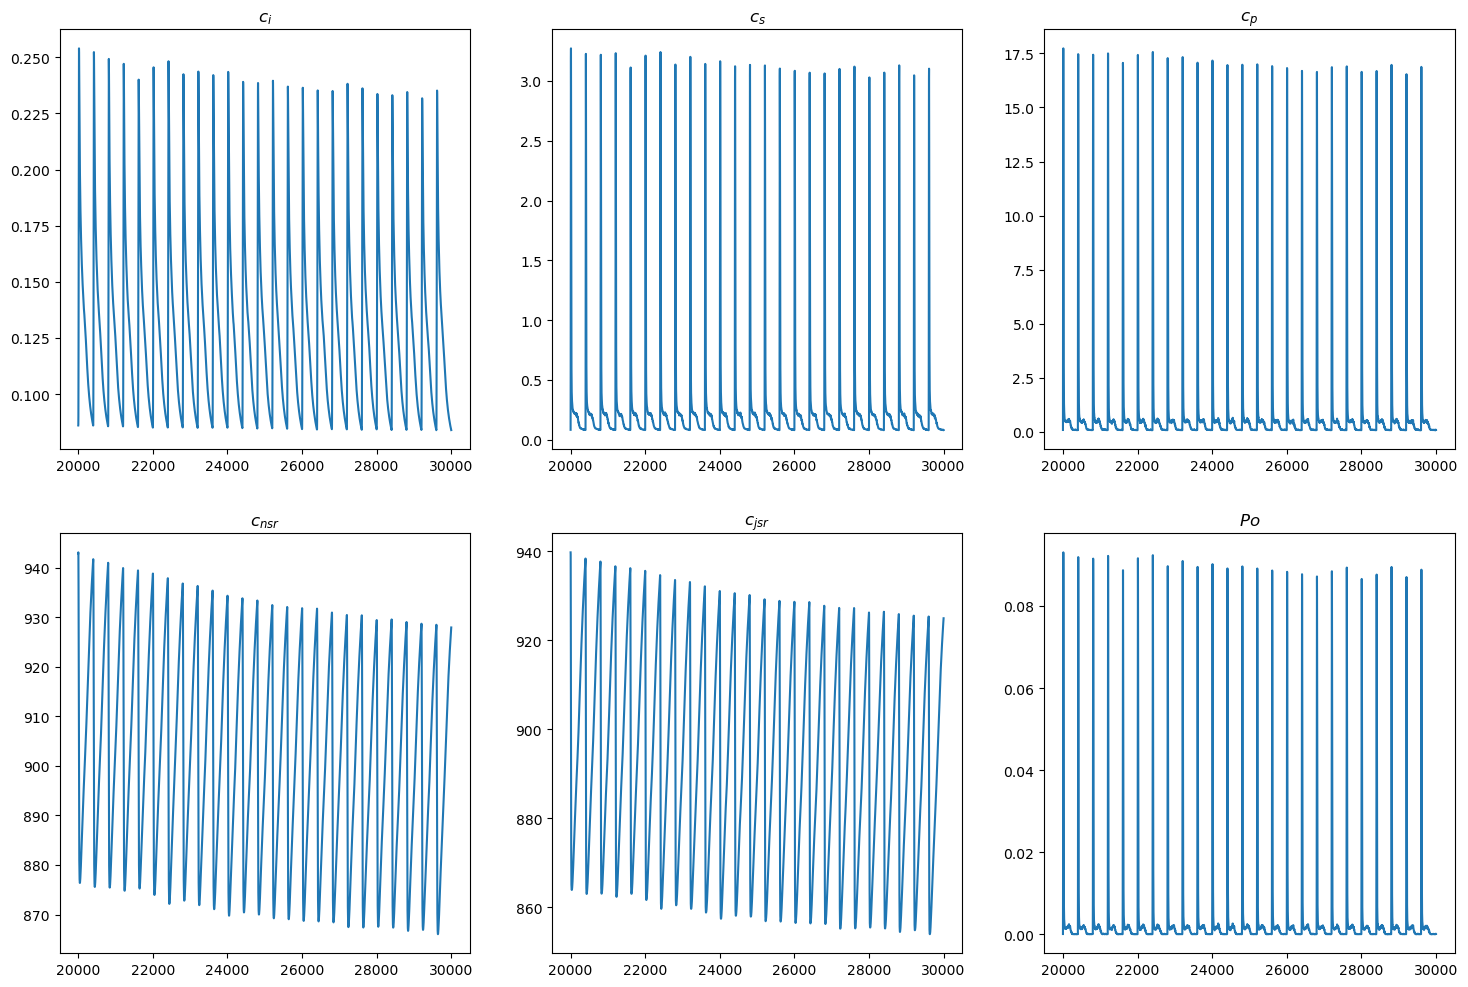

In [28]:
fig, ax = plt.subplots(2, 3, figsize=(18,12))
ax[0, 0].plot(sol.t, sol.ci.mean(axis=(1,2,3)))
#ax[0, 0].plot(sol_rapid.t, sol_rapid.ci.mean(axis=(1,2,3)))
ax[0, 0].set_title(r"$c_i$")

ax[0, 1].plot(sol.t, sol.cs.mean(axis=(1,2,3)))
#ax[0, 1].plot(sol_rapid.t, sol_rapid.cs.mean(axis=(1,2,3)))
ax[0, 1].set_title(r"$c_s$")

ax[0, 2].plot(sol.t, sol.cp.mean(axis=(1,2,3)))
#ax[0, 2].plot(sol_rapid.t, sol_rapid.cp.mean(axis=(1,2,3)))
ax[0, 2].set_title(r"$c_p$")

ax[1, 0].plot(sol.t, sol.cnsr.mean(axis=(1,2,3)))
#ax[1, 0].plot(sol_rapid.t, sol_rapid.cnsr.mean(axis=(1,2,3)))
ax[1, 0].set_title(r"$c_{nsr}$")

ax[1, 1].plot(sol.t, sol.cjsr.mean(axis=(1,2,3)))
#ax[1, 1].plot(sol_rapid.t, sol_rapid.cjsr.mean(axis=(1,2,3)))
ax[1, 1].set_title(r"$c_{jsr}$")

ax[1, 2].plot(sol.t, sol.RyR[..., 1:3].sum(axis=-1).mean(axis=(1,2,3)))
#ax[1, 2].plot(sol_rapid.t, sol_rapid.RyR[..., 1:3].sum(axis=-1).mean(axis=(1,2,3)))
ax[1, 2].set_title(r"$Po$")


plt.show()

In [84]:
def total_mol(sol, vp):
    cp_mol = sol.cp * vp[None, ...]
    cs_mol = sol.cs * sol.params.vs
    ci_mol = sol.ci * sol.params.vi
    cjsr_mol = sol.cjsr * sol.params.vjsr
    cnsr_mol = sol.cnsr * sol.params.vnsr
    return cp_mol + cs_mol + ci_mol + cjsr_mol + cnsr_mol

In [87]:
def total_buffered(sol):
    CaTi_mol = sol.CaTi * sol.params.vi
    CaTs_mol = sol.CaTs * sol.params.vs
    return CaTi_mol + CaTs_mol

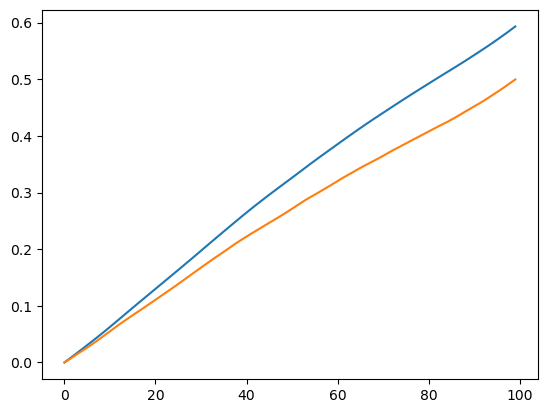

In [98]:
plt.plot((sol_diff.cnsr.mean(axis=(1,2,3))[500:600] - sol_diff.cnsr.mean(axis=(1,2,3))[500]) * params.vnsr)
plt.plot((sol_diff.cjsr.mean(axis=(1,2,3))[500:600] - sol_diff.cjsr.mean(axis=(1,2,3))[500]) * params.vjsr)
plt.show()

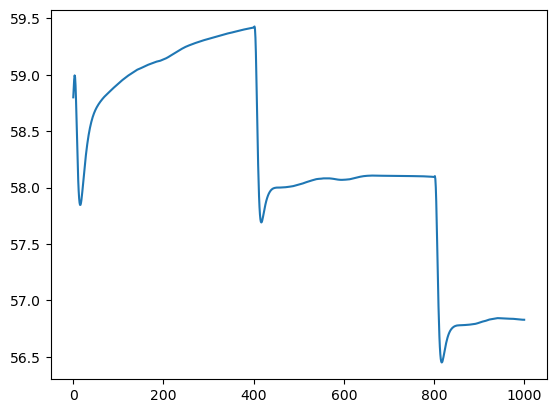

In [91]:
plt.plot(total_mol(sol_diff, cru3d_diff.vp).mean(axis=(1,2,3)) + total_buffered(sol_diff).mean(axis=(1,2,3)))
plt.show()

In [14]:
def ccdf(ax, arr):
    nsamples = len(arr)
    p_vals = np.linspace(1, nsamples+1, num=nsamples) / nsamples
    ax.plot(np.sort(arr), p_vals[::-1])
    return ax

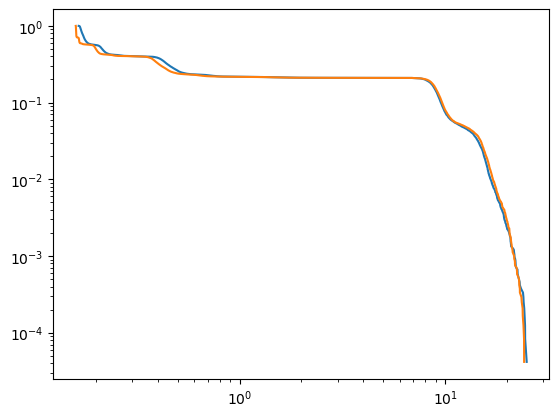

In [15]:
fig, ax = plt.subplots(1)
ax = ccdf(ax, sol_diff.cp.mean(axis=0).reshape(-1))
ax = ccdf(ax, sol_tau.cp.mean(axis=0).reshape(-1))
ax.set_xscale('log')
ax.set_yscale('log')
plt.show()

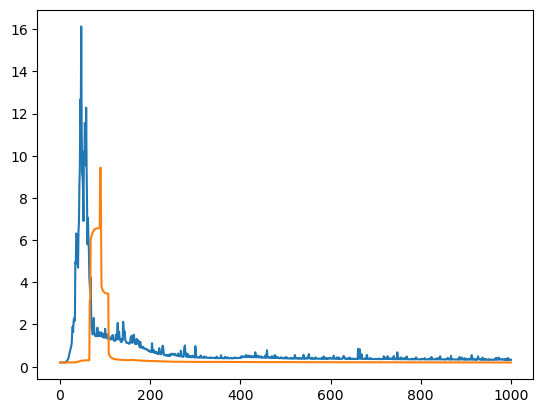

In [31]:
plt.plot(sol_diff.cp[:, 28, 14, 18])
plt.plot(sol_tau.cp[:, 11, 16, 2])
plt.show()

In [22]:
np.where(sol_tau.cp > 1.0)

(array([   0,    0,    0, ..., 1000, 1000, 1000]),
 array([ 2,  6, 11, ..., 50, 51, 57]),
 array([ 1, 13, 16, ..., 11, 10, 11]),
 array([ 9,  1,  2, ..., 13,  3,  6]))

In [83]:
ci = 0.2 * np.ones((200, 200), dtype=np.float32)
cs = 0.2 * np.ones((200, 200), dtype=np.float32)
cp = 0.2 * np.ones((200, 200), dtype=np.float32)

cjsr = 1100.0 * np.ones((200,200), dtype=np.float32)
cnsr = 1100.0 * np.ones((200,200), dtype=np.float32)

CaTi = 17.5 * np.ones((200,200), dtype=np.float32)
CaTs = 17.5 * np.ones((200,200), dtype=np.float32)

vp = params.vp * np.ones_like(ci)

In [10]:
RyR = RyR_stationary(cp, params)

In [11]:
#LCC = LCC_stationary(cp, 0.1, params)
LCC = np.zeros((*cp.shape, 4), dtype=np.int32)
LCC[0, ...] = 1
LCC[-1, ...] = 1
LCC[:, 0, :] = 1
LCC[:, -1, :] = 1

In [12]:
cru_obj = CRUs(params, RyR, LCC, ci, cnsr, cjsr, cs, cp, CaTi, CaTs, vp=vp)

In [13]:
cru_obj.forward(dt=1e-2, nstep=100_000, collect_every=1000, tpb2d=(8,8), tpb1d=16)

/home/luke/anaconda3/lib/python3.11/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 50 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


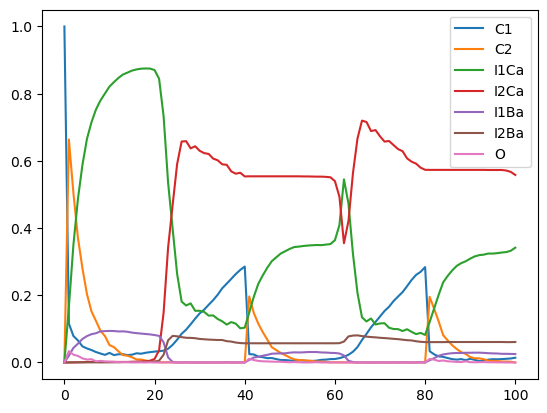

In [14]:
plt.plot((cru_obj.LCC_result == 1).sum(axis=(1,2,3)) / (796*4), label="C1")
plt.plot((cru_obj.LCC_result == 2).sum(axis=(1,2,3)) / (796*4), label="C2")
plt.plot((cru_obj.LCC_result == 3).sum(axis=(1,2,3)) / (796*4), label="I1Ca")
plt.plot((cru_obj.LCC_result == 4).sum(axis=(1,2,3)) / (796*4), label="I2Ca")
plt.plot((cru_obj.LCC_result == 5).sum(axis=(1,2,3)) / (796*4), label="I1Ba")
plt.plot((cru_obj.LCC_result == 6).sum(axis=(1,2,3)) / (796*4), label="I2Ba")
plt.plot((cru_obj.LCC_result == 7).sum(axis=(1,2,3)) / (796*4), label="O")
plt.legend()
plt.show()

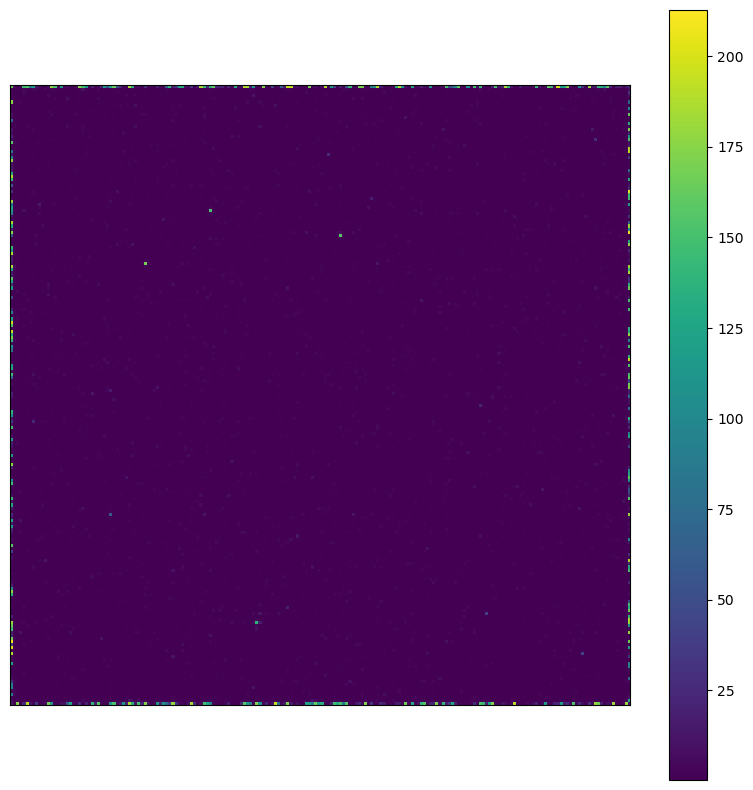

In [20]:
fig, ax = plt.subplots(1, figsize=(10,10))
im = ax.imshow(cru_obj.cp_result[1, ...], aspect='equal')
ax.set_yticks([])
ax.set_xticks([])
fig.colorbar(im)
plt.show()

In [17]:
ci_bdy = (cru_obj.ci_result[:, 0, :] + cru_obj.ci_result[:, -1, :] + cru_obj.ci_result[:, :, 0] + cru_obj.ci_result[:, :, -1]).sum(axis=1)

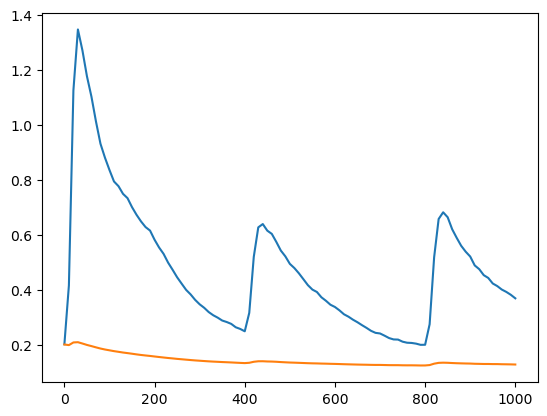

In [18]:
plt.plot(cru_obj.t, ci_bdy / (2*200 + 2*198))
plt.plot(cru_obj.t, cru_obj.ci_result.mean(axis=(1,2)))
plt.show()

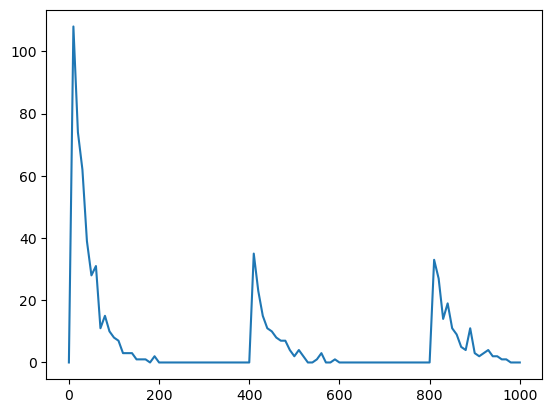

In [19]:
plt.plot(cru_obj.t, (cru_obj.LCC_result == 7).sum(axis=(1,2,3)))
plt.show()

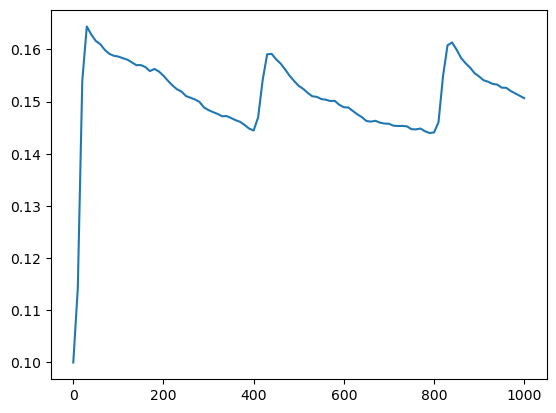

In [32]:
plt.plot(cru_obj.t, cru_obj.ci_result.mean(axis=(1,2)))
plt.show()

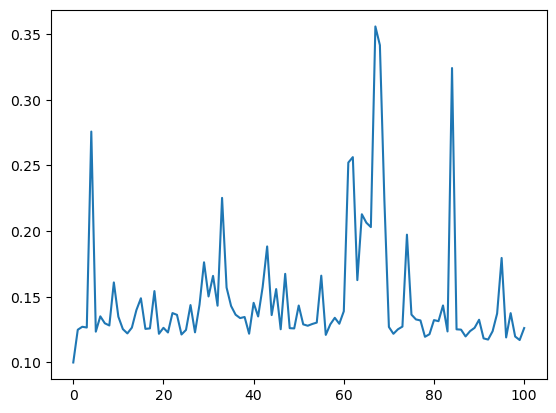

In [25]:
plt.plot(cru_obj.t, cru_obj.cs_result[:,10,10])
plt.show()

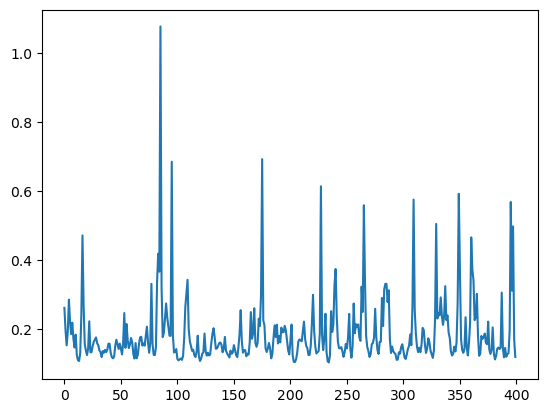

In [12]:
plt.plot(cru_obj.ci_result[-1, -1, :])
plt.show()

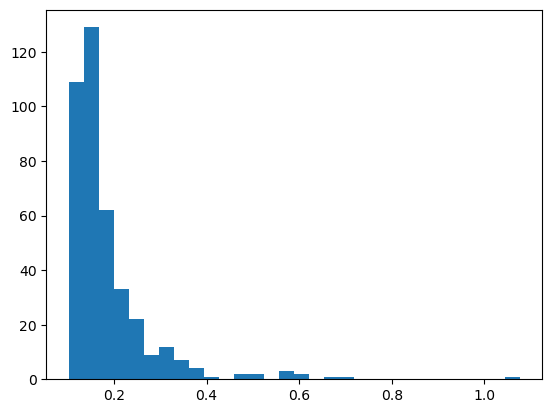

In [13]:
plt.hist(cru_obj.ci_result[-1, -1, :], bins=30)
plt.show()

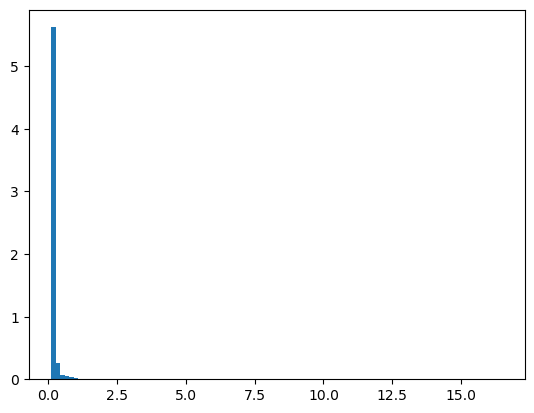

In [14]:
plt.hist(cru_obj.cs.reshape(-1), bins=100, density=True)
plt.show()

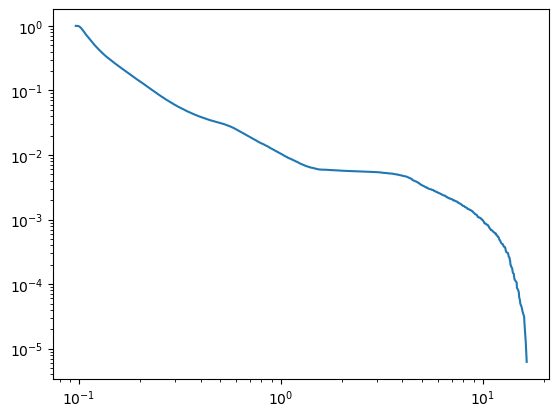

In [15]:
def ccdf(arr):
    ps = np.arange(1, len(arr)+1) / len(arr)
    vals = np.sort(arr)[::-1]
    return ps, vals

ps, bins = ccdf(cru_obj.cs.reshape(-1))
plt.plot(bins, ps)
plt.xscale('log')
plt.yscale('log')
plt.show()

In [16]:
from scipy.fft import fft2, ifft2, fftfreq, fftshift, ifftshift

In [17]:
modes = ifftshift(fft2(fftshift((cru_obj.ci - cru_obj.ci.mean())), norm="ortho"))

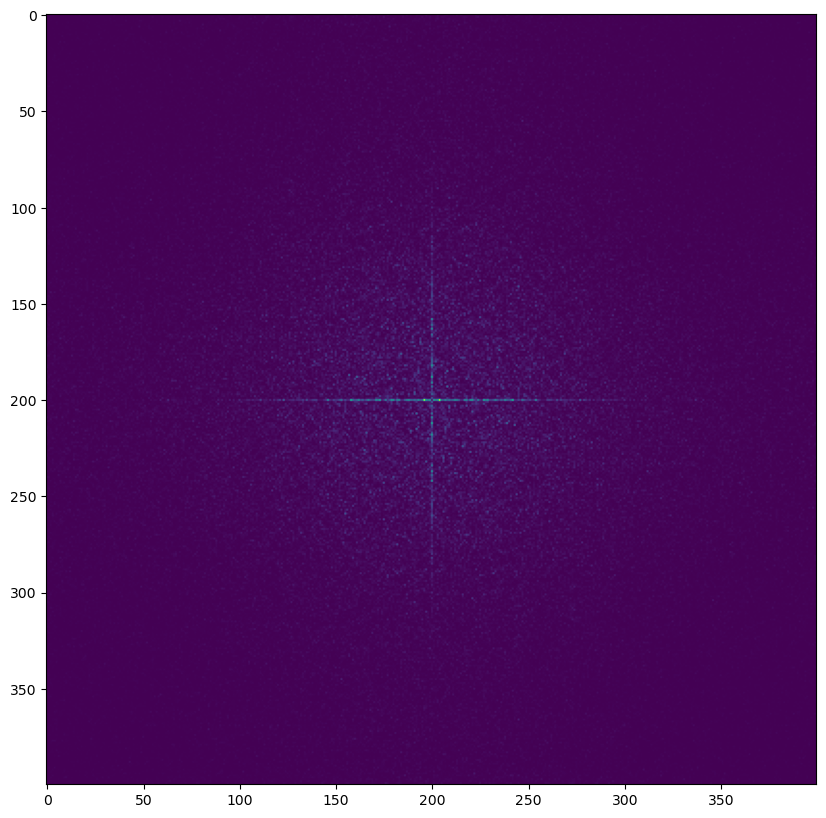

In [18]:
fig, ax = plt.subplots(1, figsize=(10,10))
ax.imshow(np.abs(modes)**2)
plt.show()

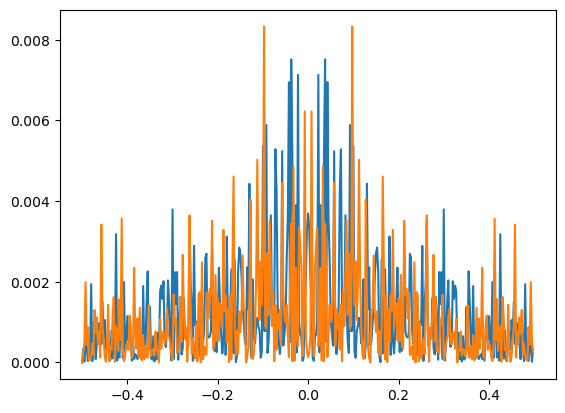

In [19]:
freqs = fftshift(fftfreq(modes[0,:].shape[0]))
plt.plot(freqs, np.abs(modes)[:, 0]**2)
plt.plot(freqs, np.abs(modes)[0, :]**2)
plt.show()

In [20]:
autocor = ifftshift(ifft2(fftshift(np.abs(modes)**2), norm="ortho"))

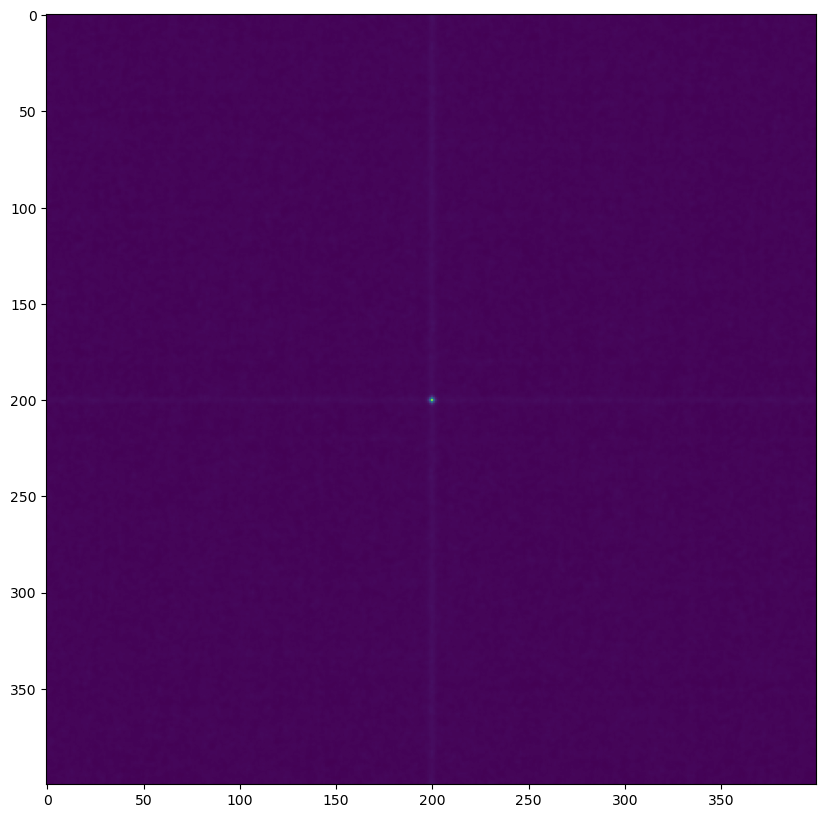

In [21]:
fig, ax = plt.subplots(1, figsize=(10,10))
ax.imshow(autocor.real)
plt.show()

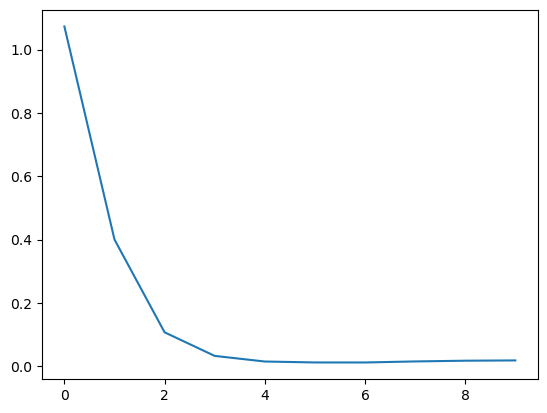

In [22]:
plt.plot(autocor[autocor.shape[0]//2, (autocor.shape[0]//2):(autocor.shape[0]//2+10)].real)
plt.show()